# Spots Size

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

In [2]:
import sys

sys.path.append(str(Path('../..').parent))

from utils import plot_stim

In [3]:
import yaml

with open('../../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [4]:
crop_setup1_h = config["qdspy"]["crop"]["setup1"]["h"]
crop_setup1_v = config["qdspy"]["crop"]["setup1"]["v"]

crop_setup3_h = config["qdspy"]["crop"]["setup3"]["h"]
crop_setup3_v = config["qdspy"]["crop"]["setup3"]["v"]

In [5]:
out_dir = Path(config["output_dir"])
os.makedirs(out_dir, exist_ok=True)

In [6]:
qdspy_export_dir = Path(config["qdspy"]["export_dir"])
os.listdir(qdspy_export_dir)

['SpotsSize_60Hz_10um_pixels.mp4',
 'SpotsSize_60Hz_10um_pixels.npz',
 'SpotsSize_60Hz_10um_pixels_mark.npz']

In [7]:
spots_file = 'SpotsSize_60Hz_10um_pixels.npz'
spots_mark_file = 'SpotsSize_60Hz_10um_pixels_mark.npz'

In [8]:
spots = np.load(os.path.join(qdspy_export_dir, spots_file))['data']
spots = np.round(np.mean(spots, axis=-1)).astype(int)
spots.shape

(2040, 120, 120)

In [9]:
spots_mark = np.load(os.path.join(qdspy_export_dir, spots_mark_file))['data']
spots_mark = np.append(spots_mark[:-1] & (~spots_mark[1:]), False)
spots_mark

array([False, False, False, ..., False, False, False], shape=(2040,))

In [10]:
time_spots = np.arange(spots.shape[0]) * 1./60.

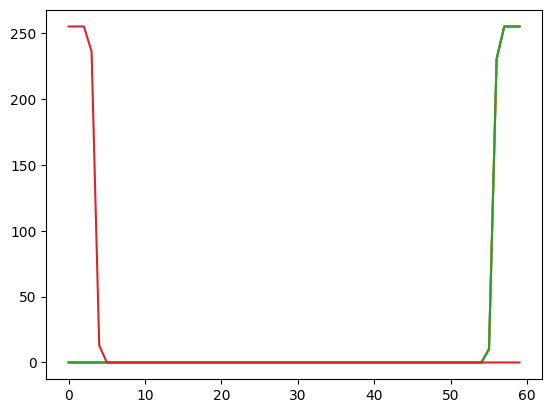

In [11]:
# Checking that the stimulus is centered correctly

x_center = spots.shape[1]//2
y_center = spots.shape[2]//2
t_s = 11

plt.plot(spots[60*t_s, y_center, x_center:][::-1])
plt.plot(spots[60*t_s, y_center, :x_center])
plt.plot(spots[60*t_s, :y_center, x_center])
plt.plot(spots[60*t_s, y_center:, x_center])

plt.show()

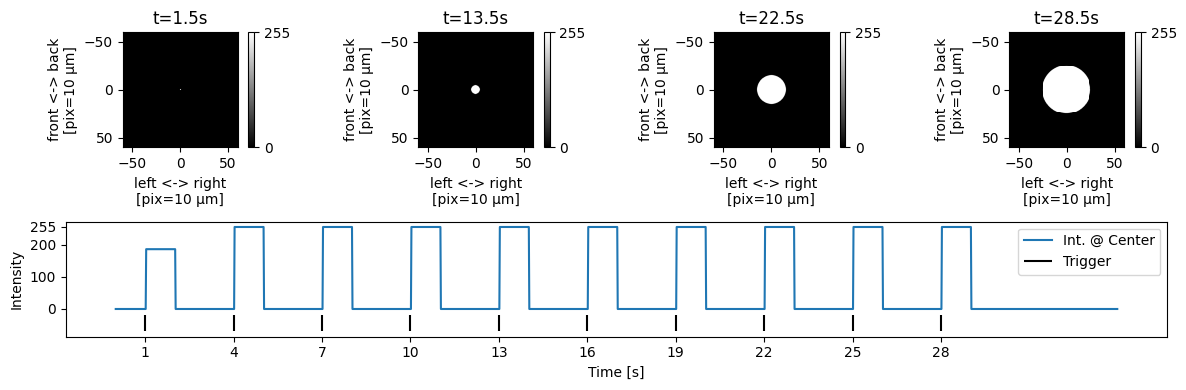

In [12]:
t_s_plot = (1.5, 13.5, 22.5, 28.5)

plot_stim(spots, spots_mark, time_spots, t_s_plot=t_s_plot);

In [13]:
spots_setup1 = spots[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]
spots_setup3 = spots[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]

In [17]:
stim_dict = {
    ('SpotsSize', '1'): spots_setup1,
    #('SpotsSize', '3'): spots_setup3,  # the same for both setups, so we only plot one
}

Plotting SpotsSize setup 1


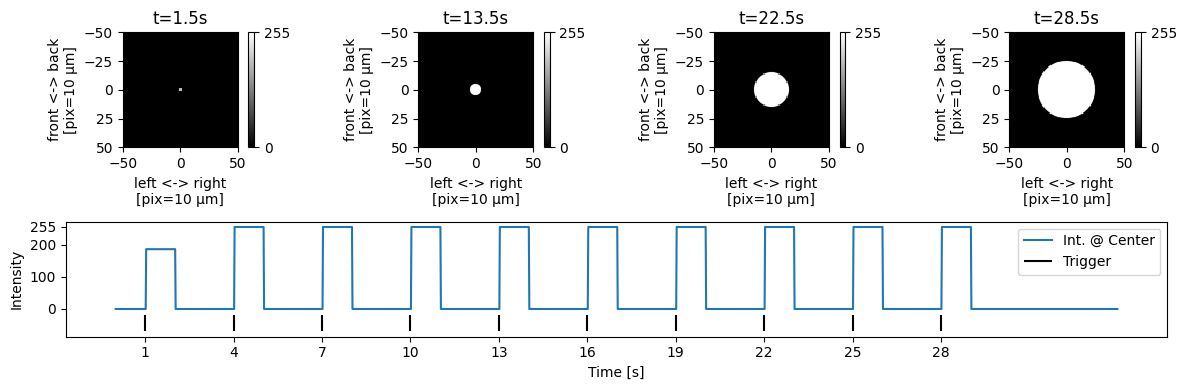

In [18]:
for (name, setup), stim in stim_dict.items():
    print(f'Plotting {name} setup {setup}')
    
    fig, axs = plot_stim(stim, spots_mark, time_spots, t_s_plot=t_s_plot)
    plt.savefig(os.path.join(out_dir, f'{name}.pdf'), bbox_inches='tight')
    plt.show()

In [20]:
target_freq = 60
assert np.isclose(target_freq, np.round(1 / np.mean(np.diff(time_spots))))


assert np.all(spots_setup1.astype(np.uint8) == spots_setup1)

np.savez_compressed(
    os.path.join(out_dir, 'SpotsSize_movie_and_trigger'),  # This stimulus is the same on all setups
    stimulus=spots_setup1.astype(np.uint8),
    time=time_spots.astype(np.float32),
    trigger=spots_mark,
    framerate=target_freq,
)